# **Prepare datasets**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

In [3]:
db = sqlite3.connect('database_kasa.db', check_same_thread = False)
q_data = 'SELECT * FROM data'
data = pd.read_sql_query(q_data, db)
data.head()


,Tweet,Label
0,warung ini dimiliki oleh pengusaha pabrik tahu...,positive
1,mohon ulama lurus dan k mmbri hujjah partai ap...,neutral
2,lokasi strategis di jalan sumatra bandung temp...,positive
3,betapa bahagia nya diri ini saat unboxing pake...,positive
4,aduh jadi mahasiswa jangan sombong dong kasih ...,negative


In [4]:
data.shape

(10933, 2)

In [5]:
data.Label.value_counts()

positive    6383
negative    3412
neutral     1138
Name: Label, dtype: int64

# **Feature Extraction: Bag of Words**

Setelah itu kita lakukan Feature Extraction menggunakan metode Bag of Words

In [6]:
# Kita simpan teks ke dalam sebuah variabel
data_preprocessed = data.Tweet.tolist()

In [7]:
data_preprocessed

['warung ini dimiliki oleh pengusaha pabrik tahu yang sudah puluhan tahun terkenal membuat tahu putih di bandung tahu berkualitas dipadu keahlian memasak dipadu kretivitas jadilah warung yang menyajikan menu utama berbahan tahu ditambah menu umum lain seperti ayam semuanya selera indonesia harga cukup terjangkau jangan melewati tahu bletoka nya tidak kalah dengan yang asli dari tegal ',
 'mohon ulama lurus dan k mmbri hujjah partai apa yang harus diwlh agar suara islam tidak pecah pecah',
 'lokasi strategis di jalan sumatra bandung tempat nya nyaman terutama sofa di lantai paella nya enak sangat pas dimakan dengan minum bir dingin appetiser nya juga enak enak ',
 'betapa bahagia nya diri ini saat unboxing paket dan barang nya bagus menetapkan beli lagi ',
 'aduh jadi mahasiswa jangan sombong dong kasih kartu kuning segala belajar dulu yang baik tidak usahlah ikut ikut politik nanti sudah selesai kuliah nya mau ikut politik juga tidak telat dasar mahasiswa ',
 'makanan beragam harga mak

In [8]:
# Untuk melakukan Feature Extraction, kita menggunakan library "Sklearn atau scikit-learn".
# Sklearn adalah library untuk melakukan task-task Machine Learning.
# "CountVectorizer" merupakan salah satu modul untuk melakukan "BoW"

from sklearn.feature_extraction.text import CountVectorizer

# Kita proses Feature Extraction
count_vect = CountVectorizer()
count_vect.fit(data_preprocessed)

X = count_vect.transform(data_preprocessed)
print ("Feature Extraction selesai")

Feature Extraction selesai


In [9]:
import pickle

pickle.dump(count_vect, open("feature.p", "wb"))

# **Prepare train & test datasets/Splitting Dataset**

Split dataset menjadi 80% untuk train dan 20% untuk test.

In [10]:
from sklearn.model_selection import train_test_split

classes = data.Label

In [11]:
classes

0        positive
1         neutral
2        positive
3        positive
4        negative
           ...   
10928     neutral
10929    positive
10930    positive
10931    negative
10932    positive
Name: Label, Length: 10933, dtype: object

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, classes, test_size = 0.3)

# Training (Neural Network)

Jalankan training dengan metode Neural Network. "MLPClassifier" merupakan salah satu modul dari "Neural Network" pada library Sklearn.

In [13]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(activation='relu', alpha=0.0001, batch_size=32, beta_1=0.9,
       beta_2=0.999, early_stopping=True, epsilon=1e-08,
       hidden_layer_sizes=(100,), learning_rate='constant',
       learning_rate_init=0.0001, max_iter=200, momentum=0.9,
       n_iter_no_change=10, nesterovs_momentum=True, power_t=0.5,
       random_state=None, shuffle=True, solver='adam', tol=0.0001,
       validation_fraction=0.1, verbose=True, warm_start=False) 
model.fit(X_train, y_train)

print ("Training selesai")

Iteration 1, loss = 0.78788838
Validation score: 0.780679
Iteration 2, loss = 0.54362888
Validation score: 0.835509
Iteration 3, loss = 0.43435924
Validation score: 0.855091
Iteration 4, loss = 0.36184385
Validation score: 0.877285
Iteration 5, loss = 0.30668298
Validation score: 0.874674
Iteration 6, loss = 0.26347188
Validation score: 0.885117
Iteration 7, loss = 0.22828995
Validation score: 0.885117
Iteration 8, loss = 0.20004175
Validation score: 0.886423
Iteration 9, loss = 0.17647389
Validation score: 0.889034
Iteration 10, loss = 0.15708460
Validation score: 0.887728
Iteration 11, loss = 0.14033292
Validation score: 0.886423
Iteration 12, loss = 0.12626451
Validation score: 0.882507
Iteration 13, loss = 0.11384897
Validation score: 0.890339
Iteration 14, loss = 0.10305787
Validation score: 0.887728
Iteration 15, loss = 0.09363690
Validation score: 0.887728
Iteration 16, loss = 0.08533758
Validation score: 0.887728
Iteration 17, loss = 0.07798287
Validation score: 0.887728
Iterat

In [14]:
pickle.dump(model, open("model.p", "wb"))

# **Evaluation**

Langkah selanjutnya adalah "Evaluation". Module "classification_report" dari Sklearn merupakan salah satu modul untuk melakukan "Evaluation". Pada tahap evaluasi ini kita akan menerapkan metode evaluasi Accuracy, Precision, Recall dan F1-Score.

In [15]:
from sklearn.metrics import classification_report
import pickle

pickled_model = pickle.load(open('model.p', 'rb'))

test = pickled_model.predict(X_test)

print ("Testing selesai")

print(classification_report(y_test, test)) 

Testing selesai
              precision    recall  f1-score   support

    negative       0.83      0.84      0.83      1084
     neutral       0.85      0.75      0.80       351
    positive       0.90      0.92      0.91      1845

    accuracy                           0.87      3280
   macro avg       0.86      0.84      0.85      3280
weighted avg       0.87      0.87      0.87      3280



## **Cross Validation**

Mekanisme evaluasi selanjutnya menggunakan "Cross Validation", yaitu merotasi porsi testing dari dataset agar bisa melihat model yang sudah kita buat stabil ketika dihadapkan pada data yang berbeda.

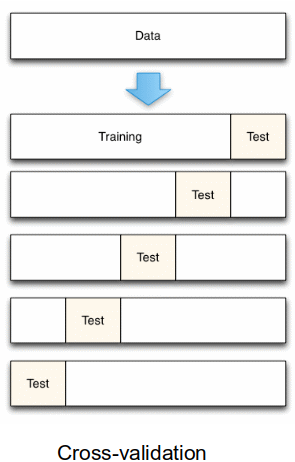

In [16]:
# Untuk lebih menyakinkan lagi, kita juga bisa melakukan "Cross Validation"
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

kf = KFold(n_splits=5,random_state=42,shuffle=True)

accuracies = []

y = classes

for iteration, data in enumerate(kf.split(X), start=1):

    data_train   = X[data[0]]
    target_train = y[data[0]]

    data_test    = X[data[1]]
    target_test  = y[data[1]]

    clf = MLPClassifier()
    clf.fit(data_train,target_train)

    preds = clf.predict(data_test)

    # for the current fold only    
    accuracy = accuracy_score(target_test,preds)

    print("Training ke-", iteration)
    print(classification_report(target_test,preds))
    print("======================================================")

    accuracies.append(accuracy)

# this is the average accuracy over all folds
average_accuracy = np.mean(accuracies)

print()
print()
print()
print("Rata-rata Accuracy: ", average_accuracy)

Training ke- 1
              precision    recall  f1-score   support

    negative       0.80      0.81      0.80       690
     neutral       0.79      0.71      0.75       220
    positive       0.89      0.90      0.89      1277

    accuracy                           0.85      2187
   macro avg       0.83      0.80      0.81      2187
weighted avg       0.85      0.85      0.85      2187



Hasilnya nilai rata-rata accuracy pada angka 0.84. Ini menunjukkan model kita cukup stabil pada angka 0.84.

# Predict

Asumsi kita sudah oke dengan model yang dibikin, selanjutnya melakukan predict pada model untuk mengetes jika model sudah jalan.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect.fit(data_preprocessed)
count_vect = CountVectorizer()
count_vect.fit(data_preprocessed)

CountVectorizer()

In [ ]:
original_text =  ''' 
warung ini dimiliki oleh pengusaha pabrik tahu yang sudah puluhan tahun terkenal membuat tahu putih di bandung . tahu berkualitas , dipadu keahlian memasak , dipadu kretivitas , jadilah warung yang menyajikan menu utama berbahan tahu , ditambah menu umum lain seperti ayam . semuanya selera indonesia . harga cukup terjangkau . jangan lewatkan tahu bletoka nya , tidak kalah dengan yang asli dari tegal !	

'''
def cleansing(sent):
    string = sent.lower()
    string = re.sub(r'[^a-zA-Z0-9]', ' ', string)
    return string




# Feature Extraction
text = count_vect.transform([cleansing(original_text)])

# Kita prediksi sentimennya
result = model.predict(text)[0]
print("Sentiment:")
print()
print(result)

Sentiment:

positive
